# Mount dữ liệu và tạo hàm đọc dữ liệu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
basePath = '/content/drive/MyDrive/MOOCCubeX/Dataset/'
entitiesPath = basePath+'entities'
relationsPath = basePath+'relations'
!ls {basePath}
import json
import gzip
import bz2
import orjson

def read_jsonl_in_batches(file_path, batch_size=10000, use_orjson=True):
    """
    Đọc file JSON Lines theo từng batch và yield DataFrame.

    Parameters
    ----------
    file_path : str
        Đường dẫn tới file JSONL (có thể nén .gz hoặc .bz2)
    batch_size : int
        Số dòng mỗi batch
    use_orjson : bool
        Sử dụng orjson để tăng tốc (nếu có cài đặt)

    Yields
    ------
    pd.DataFrame
        Batch dữ liệu dưới dạng DataFrame
    """

    # Chọn thư viện parse JSON
    json_loader = orjson.loads if use_orjson else json.loads

    # Chọn method mở file (hỗ trợ file nén)
    if file_path.endswith(".gz"):
        open_func = gzip.open
    elif file_path.endswith(".bz2"):
        open_func = bz2.open
    else:
        open_func = open

    total_lines = 0
    error_lines = 0
    batch = []

    try:
        with open_func(file_path, 'rt', encoding='utf-8') as file:
            for line_num, line in enumerate(file, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    obj = json_loader(line)
                    batch.append(obj)
                except Exception as e:
                    error_lines += 1
                    print(f"[Warning] Lỗi parse JSON tại dòng {line_num}: {e}")
                    continue

                if len(batch) >= batch_size:
                    yield pd.DataFrame(batch)
                    total_lines += len(batch)
                    batch = []

            # Batch cuối
            if batch:
                yield pd.DataFrame(batch)
                total_lines += len(batch)

    except FileNotFoundError:
        print(f"[Error] File không tồn tại: {file_path}")
    except Exception as e:
        print(f"[Error] Lỗi khi đọc file: {e}")

    print(f"[Done] Đọc xong {total_lines} dòng hợp lệ, {error_lines} dòng lỗi.")

Mounted at /content/drive
course_filtered.csv	   entities
course_final_cleaned.csv   Label_3_and_5_classes.csv
course_limit_Nhom6.csv	   prerequisites
course_merged.csv	   relations
course_proportion.csv	   resource_exercise_course.parquet
Data_cleaned		   resource_video_course.parquet
data_for_Score_Struct.csv  user_course_use_labeling.parquet


In [ ]:
import pandas as pd
# Doc file du lieu course.json
problem_df = pd.concat(read_jsonl_in_batches(entitiesPath+'/problem.json'), ignore_index=True)
problem_df.head(5)

[Warning] Lỗi parse JSON tại dòng 855959: unexpected end of data: line 1 column 215 (char 214)
[Done] Đọc xong 855958 dòng hợp lệ, 1 dòng lỗi.


,problem_id,title,content,option,answer,score,type,typetext,location,context_id,exercise_id,language
0,1730,第一课 导论与三家分晋--习题,1、《资治通鉴》卷1记载：智宣子将以瑶为后，智果曰：“……瑶之贤于人者五，其不逮者一也。美鬓...,"{'A': '武艺超群，精通射御之术', 'B': '礼贤下士，虚怀若谷', 'C': '反...","[""B""]",1.0,1,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,Chinese
1,1731,第一课 导论与三家分晋--习题,2、《资治通鉴》是一部____史书。,"{'A': '纪传体', 'B': '编年体', 'C': '纪事本末体', 'D': '国...","[""B""]",1.0,1,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,Chinese
2,1732,第一课 导论与三家分晋--习题,3、《资治通鉴》原名____，后由____赐名“资治通鉴”。,"{'A': '《通鉴》；宋神宗', 'B': '《通志》；宋徽宗', 'C': '《通鉴》；...","[""D""]",1.0,1,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,Chinese
3,1733,第一课 导论与三家分晋--习题,4、“三家分晋”中“三家”具体指：,"{'A': '魏赵韩', 'B': '魏韩智', 'C': '赵韩智', 'D': '魏赵智'}","[""A""]",1.0,1,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,Chinese
4,1734,第一课 导论与三家分晋--习题,5、智伯联合韩、魏的军队攻打赵氏时，赵襄子选择退守的阵地是：,"{'A': '邯郸', 'B': '长子', 'C': '晋阳', 'D': '皋狼'}","[""C""]",1.0,1,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,Chinese


# Phân tích cơ bản về problem.json

In [ ]:
# So luong null cua moi cot
problem_df.isnull().sum()

,0
problem_id,0
title,0
content,0
option,48752
answer,0
score,7202
type,0
typetext,0
location,0
context_id,0


In [ ]:
# So gia tri phan biet cua cot 	answer
problem_df['answer'].value_counts()

,count
answer,
"[""B""]",136543
"[""A""]",130795
"[""C""]",121033
"[""true""]",105379
"[""D""]",95764
...,...
"{""1"": [""human resources""]}",1
"{""1"": [""stocks""]}",1
"{""1"": [""commerce""]}",1


In [ ]:
# Gom nhóm các problem theo type
problem_each_type = problem_df[['type','score']].groupby('type').agg(['mean','median','std','min','max'])
print(problem_each_type)

         score                             
          mean median       std  min    max
type                                       
1     1.119107    1.0  0.883507  0.0  100.0
2     2.162170    2.0  1.418542  0.0   60.0
3     1.022989    1.0  0.695428  0.0    5.0
4     1.804920    1.0  2.006051  0.0   60.0
5     9.593078   10.0  4.556236  0.0  100.0
6     1.094724    1.0  0.736492  0.2   50.0


# Điền thiếu dữ liệu option và score

In [ ]:
# Điền giá trị thiếu trong cột 'score' bằng trung vị của từng 'type'
problem_df['score'] = problem_df.groupby('type')['score'].transform(lambda x: x.fillna(x.median()))

# Kiểm tra lại số lượng null sau khi điền
print("Số lượng null của cột 'score' sau khi điền:", problem_df['score'].isnull().sum())

Số lượng null của cột 'score' sau khi điền: 0


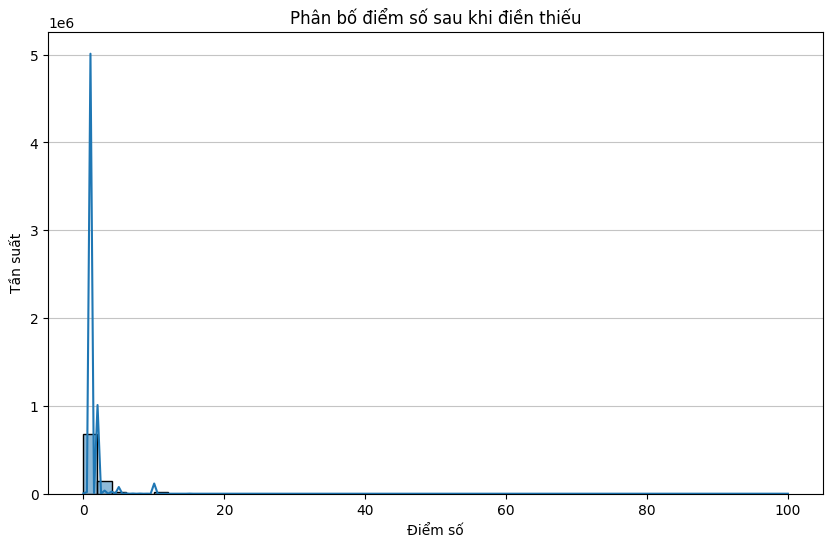

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Phân bố dữ liệu điểm sau điền thiếu
plt.figure(figsize=(10, 6))
sns.histplot(problem_df['score'], bins=50, kde=True)
plt.title('Phân bố điểm số sau khi điền thiếu')
plt.xlabel('Điểm số')
plt.ylabel('Tần suất')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Điền chuỗi rỗng cho dữ liệu về option
problem_df['option'].fillna('', inplace=True)

/tmp/ipython-input-2067942186.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  problem_df['option'].fillna('', inplace=True)


In [ ]:
problem_df.isna().sum()

,0
problem_id,0
title,0
content,0
option,0
answer,0
score,0
type,0
typetext,0
location,0
context_id,0


## Mã hóa cột type và language

In [ ]:
import pandas as pd

# Mã hóa các cột phân loại ('language', 'type') bằng One-Hot Encoding
problem_df_encoded = pd.get_dummies(problem_df, columns=['language', 'type'], dtype=int)

# Hiển thị 5 dòng đầu và thông tin về các cột mới
print(problem_df_encoded.head())
print("\nThông tin DataFrame sau khi mã hóa:")
problem_df_encoded.info()

   problem_id            title  \
0        1730  第一课 导论与三家分晋--习题   
1        1731  第一课 导论与三家分晋--习题   
2        1732  第一课 导论与三家分晋--习题   
3        1733  第一课 导论与三家分晋--习题   
4        1734  第一课 导论与三家分晋--习题   

                                             content  \
0  1、《资治通鉴》卷1记载：智宣子将以瑶为后，智果曰：“……瑶之贤于人者五，其不逮者一也。美鬓...   
1                                 2、《资治通鉴》是一部____史书。   
2                     3、《资治通鉴》原名____，后由____赐名“资治通鉴”。   
3                                  4、“三家分晋”中“三家”具体指：   
4                     5、智伯联合韩、魏的军队攻打赵氏时，赵襄子选择退守的阵地是：   

                                              option answer  score typetext  \
0  {'A': '武艺超群，精通射御之术', 'B': '礼贤下士，虚怀若谷', 'C': '反...  ["B"]    1.0      单选题   
1  {'A': '纪传体', 'B': '编年体', 'C': '纪事本末体', 'D': '国...  ["B"]    1.0      单选题   
2  {'A': '《通鉴》；宋神宗', 'B': '《通志》；宋徽宗', 'C': '《通鉴》；...  ["D"]    1.0      单选题   
3   {'A': '魏赵韩', 'B': '魏韩智', 'C': '赵韩智', 'D': '魏赵智'}  ["A"]    1.0      单选题   
4       {'A': '邯郸', 'B': '长子', 'C': '晋阳', 'D': '皋狼'}  ["C"]    

# Đọc dữ liệu các khóa học có thông tin tỷ lệ điểm và exercise của khóa học

In [ ]:
# Đọc dữ liệu resource_exercise_course.parquet
resource_exercise_course_df = pd.read_parquet(basePath+'resource_exercise_course.parquet')
# Dọc dữ liệu user_course_use_labeling.csv
user_course_use_labeling_df = pd.read_parquet(basePath+'user_course_use_labeling.parquet')


In [ ]:
resource_exercise_course_df

,id,titles_chapter,title_exercise,chapter,ex_id,ex_counts
0,C_1017355,"[Unit 1 Introduction to Chinese Medicine, Unit...","[1.1 Brief History of Chinese Medicine, 1.2\t...","[0.1, 0.1.1, 1.1, 1.1.1, 1.1.2, 1.2.2, 2.1, 2....","[Ex_1617853, Ex_1617855, Ex_1736572, Ex_173657...",19
1,C_1017419,"[课程简介, 第一讲 智慧政府：智慧金融, 第二讲 智慧政府：政务服务, 第三讲 智慧交通：...","[你对智慧政府的认识, 智慧金融, 智慧公共服务, 智慧交通能治堵吗？, 看病难，看病贵如何...","[1.3, 2.3, 3.3, 4.3, 5.3, 6.3, 7.3, 8.3, 9.3]","[Ex_1618248, Ex_1618251, Ex_1618254, Ex_161825...",9
2,C_1025064,"[第1章 思想政治教育与思想政治教育学述要, 第2章 思想政治教育的发生与发展, 第3...","[第1章测验, 第2章测验, 第3章测验, 第4章测验, 第5章测验, 第6章测验, 第7章...","[0.6, 1.7, 2.4, 3.2, 4.4, 5.3, 6.4, 7.4, 8.3, ...","[Ex_1622556, Ex_1622566, Ex_1622574, Ex_162258...",14
3,C_1025076,"[第一章 轮滑运动规则与赏析, 第二章 速度轮滑经典训练理论与方法, 第二章 速度轮滑经典训...","[第2节 全球经典轮滑特色赛事活动介绍与赏析, 第二章测验, 第二章作业, 第三章作业]","[0.2.6, 1.2, 1.3, 2.11]","[Ex_1622870, Ex_1622875, Ex_1622876, Ex_1622889]",4
4,C_1025079,"[第一周, 第四周, 第五周, 第七周, 第八周]","[一、缠丝健身功功理测验, 二、核心分部缠丝功法测验, 三、肩臂联合缠丝功法测验, 四、胸背...","[1.5, 4.5, 5.5, 7.5, 8.3]","[Ex_1622993, Ex_1623006, Ex_1623011, Ex_162302...",5
...,...,...,...,...,...,...
3199,C_955163,"[1. 课程导论, 2. 如何开始第一步, 3. 产品原型设计实践, 4. 小程序前端开发实...","[测试1, 测试2, 测试3, 测试2：第4章, 测试5, 测试6, 测试7]","[0.4, 1.1, 2.19, 3.21, 4.43, 5.12, 6.1]","[Ex_1576375, Ex_1576376, Ex_1545423, Ex_154542...",7
3200,C_956128,"[第一章 门静脉高压病理生理和治疗, 第二章 门静脉高压治疗方法的辨析, 第三章 EVB的处...","[第一章测试 门静脉高压病理生理和治疗, 第二章测试 门静脉高压治疗方法的辨析, 第三章测试...","[0.2, 1.3, 2.4, 3.3, 4.3, 5.2, 6.3]","[Ex_1555008, Ex_1555014, Ex_1555021, Ex_155502...",7
3201,C_956129,"[第一章 定义游戏, 第一章 定义游戏, 第一章 定义游戏, 第一章 定义游戏, 第二章 游...","[1.1 什么是游戏，什么是电子游戏, 1.2 游戏的平台, 1.3 游戏的类型, 1.4...","[0.5, 0.1.4, 0.2.7, 0.3.3, 1.5, 1.1.2, 1.2.5, ...","[Ex_1555101, Ex_1555106, Ex_1555114, Ex_155511...",23
3202,C_956130,"[第一章 多媒体技术概述, 第一章 多媒体技术概述, 第一章 多媒体技术概述, 第一章...","[作业：多媒体技术的背景及现状, 作业：多媒体的基本概念, 作业：多媒体系统的组成, 作业：...","[0.1, 0.3, 0.5, 0.7, 0.9, 1.6.15, 1.1, 1.3, 2....","[Ex_6304318, Ex_6304321, Ex_6304325, Ex_630432...",15


In [ ]:
user_course_use_labeling_df

,user_id,course_id,enroll_time,Video,Assignment,Exam
0,U_22,C_682129,2019-10-12 10:28:02,0.0,30.0,70.0
1,U_24,C_597314,2019-06-12 17:22:07,40.0,60.0,0.0
2,U_24,C_597208,2019-06-17 15:22:41,0.0,100.0,0.0
3,U_24,C_682129,2019-10-06 16:23:51,0.0,30.0,70.0
4,U_24,C_674910,2019-10-08 17:51:04,40.0,60.0,0.0
...,...,...,...,...,...,...
8546036,U_34712111,C_2199449,2020-10-12 03:46:08,30.0,50.0,20.0
8546037,U_34712112,C_916828,2020-10-12 03:51:36,20.0,50.0,30.0
8546038,U_34712114,C_735405,2020-10-12 03:57:05,10.0,50.0,40.0
8546039,U_34712115,C_676937,2020-10-20 20:32:10,20.0,80.0,0.0


In [ ]:
# Loại bỏ cột id_y và đổi tên cột id_x thành user_id của  user_course_use_labeling_df
user_course_use_labeling_df = user_course_use_labeling_df.drop(columns=['id_y']).rename(columns={'id_x': 'user_id'})


KeyError: "['id_y'] not found in axis"

# Lọc dữ liệu của problem và exercise theo tiêu chí:
 - Chỉ giữ lại những exercise có thông tin về problem trong problem.json
 - Thêm trường dữ liệu course_id vào problem__df_encoded nhằm loại bỏ các problem không thuộc trong khóa học có điểm thành phần.

In [ ]:
# Lấy ra những course_id duy nhât từ user_course_use_labeling_df
unique_course_ids = user_course_use_labeling_df['course_id'].unique()

In [ ]:
unique_course_ids.shape

(2232,)

In [ ]:
# Giữ lại những dòng dữ liệu có course_id trong unique_course_ids của data frame resource_exercise_course_df
resource_exercise_course_df = resource_exercise_course_df[resource_exercise_course_df['id'].isin(unique_course_ids)]

In [ ]:
resource_exercise_course_df

,id,titles_chapter,title_exercise,chapter,ex_id,ex_counts
0,C_1017355,"[Unit 1 Introduction to Chinese Medicine, Unit...","[1.1 Brief History of Chinese Medicine, 1.2\t...","[0.1, 0.1.1, 1.1, 1.1.1, 1.1.2, 1.2.2, 2.1, 2....","[Ex_1617853, Ex_1617855, Ex_1736572, Ex_173657...",19
1,C_1017419,"[课程简介, 第一讲 智慧政府：智慧金融, 第二讲 智慧政府：政务服务, 第三讲 智慧交通：...","[你对智慧政府的认识, 智慧金融, 智慧公共服务, 智慧交通能治堵吗？, 看病难，看病贵如何...","[1.3, 2.3, 3.3, 4.3, 5.3, 6.3, 7.3, 8.3, 9.3]","[Ex_1618248, Ex_1618251, Ex_1618254, Ex_161825...",9
2,C_1025064,"[第1章 思想政治教育与思想政治教育学述要, 第2章 思想政治教育的发生与发展, 第3...","[第1章测验, 第2章测验, 第3章测验, 第4章测验, 第5章测验, 第6章测验, 第7章...","[0.6, 1.7, 2.4, 3.2, 4.4, 5.3, 6.4, 7.4, 8.3, ...","[Ex_1622556, Ex_1622566, Ex_1622574, Ex_162258...",14
3,C_1025076,"[第一章 轮滑运动规则与赏析, 第二章 速度轮滑经典训练理论与方法, 第二章 速度轮滑经典训...","[第2节 全球经典轮滑特色赛事活动介绍与赏析, 第二章测验, 第二章作业, 第三章作业]","[0.2.6, 1.2, 1.3, 2.11]","[Ex_1622870, Ex_1622875, Ex_1622876, Ex_1622889]",4
4,C_1025079,"[第一周, 第四周, 第五周, 第七周, 第八周]","[一、缠丝健身功功理测验, 二、核心分部缠丝功法测验, 三、肩臂联合缠丝功法测验, 四、胸背...","[1.5, 4.5, 5.5, 7.5, 8.3]","[Ex_1622993, Ex_1623006, Ex_1623011, Ex_162302...",5
...,...,...,...,...,...,...
3198,C_949542,"[第一专题 创新，我们别无选择, 第一专题 创新，我们别无选择, 第一专题 创新，我们别无选...","[1.1创新驱动时代, 1.2创新支撑创业, 1.3创新促进成长, 2.1创新思维与逻辑思维...","[0.1, 0.1.1, 0.2.1, 1.1, 1.1.1, 1.2.1, 2.1, 2....","[Ex_1505189, Ex_1505191, Ex_1505193, Ex_150519...",31
3199,C_955163,"[1. 课程导论, 2. 如何开始第一步, 3. 产品原型设计实践, 4. 小程序前端开发实...","[测试1, 测试2, 测试3, 测试2：第4章, 测试5, 测试6, 测试7]","[0.4, 1.1, 2.19, 3.21, 4.43, 5.12, 6.1]","[Ex_1576375, Ex_1576376, Ex_1545423, Ex_154542...",7
3201,C_956129,"[第一章 定义游戏, 第一章 定义游戏, 第一章 定义游戏, 第一章 定义游戏, 第二章 游...","[1.1 什么是游戏，什么是电子游戏, 1.2 游戏的平台, 1.3 游戏的类型, 1.4...","[0.5, 0.1.4, 0.2.7, 0.3.3, 1.5, 1.1.2, 1.2.5, ...","[Ex_1555101, Ex_1555106, Ex_1555114, Ex_155511...",23
3202,C_956130,"[第一章 多媒体技术概述, 第一章 多媒体技术概述, 第一章 多媒体技术概述, 第一章...","[作业：多媒体技术的背景及现状, 作业：多媒体的基本概念, 作业：多媒体系统的组成, 作业：...","[0.1, 0.3, 0.5, 0.7, 0.9, 1.6.15, 1.1, 1.3, 2....","[Ex_6304318, Ex_6304321, Ex_6304325, Ex_630432...",15


In [ ]:
# Explode DataFrame dựa trên các cột list-like
resource_exercise_course_exploded_df = resource_exercise_course_df.explode(['titles_chapter', 'title_exercise', 'chapter', 'ex_id'])

# Hiển thị thông tin và vài dòng đầu của DataFrame sau khi explode
print("Thông tin DataFrame sau khi explode:")
resource_exercise_course_exploded_df.info()
print("\n5 dòng đầu của DataFrame sau khi explode:")
print(resource_exercise_course_exploded_df.head())

Thông tin DataFrame sau khi explode:
<class 'pandas.core.frame.DataFrame'>
Index: 45231 entries, 0 to 3203
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              45231 non-null  object
 1   titles_chapter  45231 non-null  object
 2   title_exercise  45231 non-null  object
 3   chapter         45231 non-null  object
 4   ex_id           45231 non-null  object
 5   ex_counts       45231 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 2.4+ MB

5 dòng đầu của DataFrame sau khi explode:
          id                           titles_chapter  \
0  C_1017355  Unit 1 Introduction to Chinese Medicine   
0  C_1017355  Unit 1 Introduction to Chinese Medicine   
0  C_1017355                   Unit 2 Yin-yang Theory   
0  C_1017355                   Unit 2 Yin-yang Theory   
0  C_1017355                  Unit 2 Ying-yang Theory   

                                      title_exercise chapter       ex_id 

In [ ]:
# Chỉ giữ lại những dòng dữ liệu có exercise_id trong problem_df
exercise_unique_ids = problem_df['exercise_id'].unique()
resource_exercise_course_exploded_df = resource_exercise_course_exploded_df[resource_exercise_course_exploded_df['ex_id'].isin(exercise_unique_ids)]
resource_exercise_course_exploded_df.shape

(20874, 6)

In [ ]:
# Thêm cột course_id cho problem_df bằng cách merge với resource_exercise_course_exploded_df
problem_df_encoded = problem_df_encoded.merge(resource_exercise_course_exploded_df[['ex_id', 'id']], left_on= 'exercise_id', right_on='ex_id', how='inner')
# loai bo cot ex_id
problem_df_encoded = problem_df_encoded.drop(columns=['ex_id'])
# Doi ten cot id thanh course_id
problem_df_encoded = problem_df_encoded.rename(columns={'id': 'course_id'})
problem_df_encoded

,problem_id,title,content,option,answer,score,typetext,location,context_id,exercise_id,language_Chinese,language_English,type_1,type_2,type_3,type_4,type_5,type_6,course_id
0,1730,第一课 导论与三家分晋--习题,1、《资治通鉴》卷1记载：智宣子将以瑶为后，智果曰：“……瑶之贤于人者五，其不逮者一也。美鬓...,"{'A': '武艺超群，精通射御之术', 'B': '礼贤下士，虚怀若谷', 'C': '反...","[""B""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
1,1731,第一课 导论与三家分晋--习题,2、《资治通鉴》是一部____史书。,"{'A': '纪传体', 'B': '编年体', 'C': '纪事本末体', 'D': '国...","[""B""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
2,1732,第一课 导论与三家分晋--习题,3、《资治通鉴》原名____，后由____赐名“资治通鉴”。,"{'A': '《通鉴》；宋神宗', 'B': '《通志》；宋徽宗', 'C': '《通鉴》；...","[""D""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
3,1733,第一课 导论与三家分晋--习题,4、“三家分晋”中“三家”具体指：,"{'A': '魏赵韩', 'B': '魏韩智', 'C': '赵韩智', 'D': '魏赵智'}","[""A""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
4,1734,第一课 导论与三家分晋--习题,5、智伯联合韩、魏的军队攻打赵氏时，赵襄子选择退守的阵地是：,"{'A': '邯郸', 'B': '长子', 'C': '晋阳', 'D': '皋狼'}","[""C""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140561,2416818,习题10.1（共6题、满分20分）,有一个4位的D/A转换器，设它的FSR为7.5V，当输入数字量为1101时，输出电压为,"{'A': '4 V', 'B': '6.5 V', 'C': '8.25 V', 'D':...","[""B""]",2.0,单选题,10.6,[6339736],Ex_2144960,1,0,1,0,0,0,0,0,C_1410106
140562,2416819,习题10.1（共6题、满分20分）,倒T形电阻网络DAC相比权电阻网络DAC具有的优点不包含,"{'A': '电阻值范围小', 'B': '便于集成', 'C': '无寄生电容充放电现象'...","[""D""]",2.0,单选题,10.6,[6339736],Ex_2144960,1,0,1,0,0,0,0,0,C_1410106
140563,2416826,第一章作业题,组织与人力资源管理的四大匹配是刚刚匹配，人人匹配，人岗匹配和人的需求与岗位供给匹配,"{'true': '正确', 'false': '错误'}","[""true""]",1.0,判断题,5,"[6337887, 6337895, 6337904, 6337910, 6337917]",Ex_2144988,1,0,0,0,0,0,0,1,C_1410117
140564,2416827,第一章作业题,人力资源就是人力资本，两者没有任何区别。,"{'true': '正确', 'false': '错误'}","[""false""]",1.0,判断题,5,"[6337887, 6337895, 6337904, 6337910, 6337917]",Ex_2144988,1,0,0,0,0,0,0,1,C_1410117


In [ ]:
# Gom nhóm theo 'id' và tổng hợp các cột còn lại thành list, tính lại ex_counts
resource_exercise_course_regrouped_df = resource_exercise_course_exploded_df.groupby('id').agg(
    titles_chapter=('titles_chapter', list),
    title_exercise=('title_exercise', list),
    chapter=('chapter', list),
    ex_id=('ex_id', list),
    ex_counts=('ex_id', 'size') # Calculate count based on the size of the group (number of ex_ids)
).reset_index()

# Hiển thị thông tin và vài dòng đầu của DataFrame sau khi gom nhóm
print("Thông tin DataFrame sau khi gom nhóm:")
resource_exercise_course_regrouped_df.info()
print("\n5 dòng đầu của DataFrame sau khi gom nhóm:")
print(resource_exercise_course_regrouped_df.head())

Thông tin DataFrame sau khi gom nhóm:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1277 entries, 0 to 1276
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              1277 non-null   object
 1   titles_chapter  1277 non-null   object
 2   title_exercise  1277 non-null   object
 3   chapter         1277 non-null   object
 4   ex_id           1277 non-null   object
 5   ex_counts       1277 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 60.0+ KB

5 dòng đầu của DataFrame sau khi gom nhóm:
          id                                     titles_chapter  \
0  C_1017355  [Unit 1 Introduction to Chinese Medicine, Unit...   
1  C_1017419  [第一讲 智慧政府：智慧金融, 第二讲 智慧政府：政务服务, 第五讲 智慧环境：智慧的污染治...   
2  C_1025064  [第1章   思想政治教育与思想政治教育学述要, 第2章  思想政治教育的发生与发展, 第3...   
3  C_1025079                          [第一周, 第四周, 第五周, 第七周, 第八周]   
4  C_1123848                                            [1  概述]   

      

In [ ]:
resource_exercise_course_regrouped_df.describe()

,ex_counts
count,1277.000000
mean,16.346124
std,17.785314
min,1.000000
25%,6.000000
50%,10.000000
75%,21.000000
max,228.000000


In [ ]:
# Luu tru cac dataframe user_course_use_labeling_df, resource_exercise_course_regrouped_df, problem_df_encoded  vào drive


In [ ]:
# Loại bỏ cột 'Unnamed: 0' khỏi user_course_use_labeling_df
user_course_use_labeling_df = user_course_use_labeling_df.drop(columns=['Unnamed: 0'])

# Hiển thị thông tin DataFrame sau khi loại bỏ cột
print("Thông tin DataFrame sau khi loại bỏ cột 'Unnamed: 0':")
user_course_use_labeling_df.info()
print("\n5 dòng đầu của DataFrame sau khi loại bỏ cột 'Unnamed: 0':")
print(user_course_use_labeling_df.head())

KeyError: "['Unnamed: 0'] not found in axis"

In [ ]:
user_course_use_labeling_df

,user_id,course_id,enroll_time,Video,Assignment,Exam
0,U_22,C_682129,2019-10-12 10:28:02,0.0,30.0,70.0
1,U_24,C_597314,2019-06-12 17:22:07,40.0,60.0,0.0
2,U_24,C_597208,2019-06-17 15:22:41,0.0,100.0,0.0
3,U_24,C_682129,2019-10-06 16:23:51,0.0,30.0,70.0
4,U_24,C_674910,2019-10-08 17:51:04,40.0,60.0,0.0
...,...,...,...,...,...,...
8546036,U_34712111,C_2199449,2020-10-12 03:46:08,30.0,50.0,20.0
8546037,U_34712112,C_916828,2020-10-12 03:51:36,20.0,50.0,30.0
8546038,U_34712114,C_735405,2020-10-12 03:57:05,10.0,50.0,40.0
8546039,U_34712115,C_676937,2020-10-20 20:32:10,20.0,80.0,0.0


In [ ]:
resource_exercise_course_regrouped_df

,id,titles_chapter,title_exercise,chapter,ex_id,ex_counts
0,C_1017355,"[Unit 1 Introduction to Chinese Medicine, Unit...","[1.1 Brief History of Chinese Medicine, 2.1 Ba...","[0.1, 1.1, 2.1, 2.1.1, 3.1, 5.1, 6.1.1, 7.1, 7...","[Ex_1617853, Ex_1736572, Ex_1617861, Ex_161786...",9
1,C_1017419,"[第一讲 智慧政府：智慧金融, 第二讲 智慧政府：政务服务, 第五讲 智慧环境：智慧的污染治...","[智慧金融, 智慧公共服务, 生活中的智慧环保, 智慧公共安全, 智慧社区, 智慧教育与AI技术]","[2.3, 3.3, 6.3, 7.3, 8.3, 9.3]","[Ex_1618251, Ex_1618254, Ex_1618263, Ex_161826...",6
2,C_1025064,"[第1章 思想政治教育与思想政治教育学述要, 第2章 思想政治教育的发生与发展, 第3...","[第1章测验, 第2章测验, 第3章测验]","[0.6, 1.7, 2.4]","[Ex_1622556, Ex_1622566, Ex_1622574]",3
3,C_1025079,"[第一周, 第四周, 第五周, 第七周, 第八周]","[一、缠丝健身功功理测验, 二、核心分部缠丝功法测验, 三、肩臂联合缠丝功法测验, 四、胸背...","[1.5, 4.5, 5.5, 7.5, 8.3]","[Ex_1622993, Ex_1623006, Ex_1623011, Ex_162302...",5
4,C_1123848,[1 概述],[单元测试],[1.3],[Ex_1685437],1
...,...,...,...,...,...,...
1272,C_949541,"[第一章 产品设计概述, 第二章 产品设计思维与方法, 第三章 产品设计程序, 第四章 产品...","[本章习题, 本章习题, 本章习题, 本章习题, 本章习题, 本章习题, 本章习题]","[0.2, 1.4, 2.3, 3.2, 4.5, 5.6, 6.5]","[Ex_1505058, Ex_1505069, Ex_1505078, Ex_150508...",7
1273,C_949542,"[第一专题 创新，我们别无选择, 第一专题 创新，我们别无选择, 第一专题 创新，我们别无选...","[1.1创新驱动时代, 1.2创新支撑创业, 1.3创新促进成长, 2.1创新思维与逻辑思维...","[0.1, 0.1.1, 0.2.1, 1.1, 1.2.1, 2.1, 2.1.1, 2....","[Ex_1505189, Ex_1505191, Ex_1505193, Ex_150519...",25
1274,C_955163,"[1. 课程导论, 2. 如何开始第一步, 3. 产品原型设计实践, 4. 小程序前端开发实...","[测试1, 测试2, 测试3, 测试2：第4章, 测试5, 测试6, 测试7]","[0.4, 1.1, 2.19, 3.21, 4.43, 5.12, 6.1]","[Ex_1576375, Ex_1576376, Ex_1545423, Ex_154542...",7
1275,C_956129,"[第一章 定义游戏, 第一章 定义游戏, 第一章 定义游戏, 第一章 定义游戏, 第二章 游...","[1.1 什么是游戏，什么是电子游戏, 1.2 游戏的平台, 1.3 游戏的类型, 1.4...","[0.5, 0.1.4, 0.2.7, 0.3.3, 1.5, 1.1.2, 1.3.2, ...","[Ex_1555101, Ex_1555106, Ex_1555114, Ex_155511...",21


In [ ]:
problem_df_encoded

,problem_id,title,content,option,answer,score,typetext,location,context_id,exercise_id,language_Chinese,language_English,type_1,type_2,type_3,type_4,type_5,type_6,course_id
0,1730,第一课 导论与三家分晋--习题,1、《资治通鉴》卷1记载：智宣子将以瑶为后，智果曰：“……瑶之贤于人者五，其不逮者一也。美鬓...,"{'A': '武艺超群，精通射御之术', 'B': '礼贤下士，虚怀若谷', 'C': '反...","[""B""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
1,1731,第一课 导论与三家分晋--习题,2、《资治通鉴》是一部____史书。,"{'A': '纪传体', 'B': '编年体', 'C': '纪事本末体', 'D': '国...","[""B""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
2,1732,第一课 导论与三家分晋--习题,3、《资治通鉴》原名____，后由____赐名“资治通鉴”。,"{'A': '《通鉴》；宋神宗', 'B': '《通志》；宋徽宗', 'C': '《通鉴》；...","[""D""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
3,1733,第一课 导论与三家分晋--习题,4、“三家分晋”中“三家”具体指：,"{'A': '魏赵韩', 'B': '魏韩智', 'C': '赵韩智', 'D': '魏赵智'}","[""A""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
4,1734,第一课 导论与三家分晋--习题,5、智伯联合韩、魏的军队攻打赵氏时，赵襄子选择退守的阵地是：,"{'A': '邯郸', 'B': '长子', 'C': '晋阳', 'D': '皋狼'}","[""C""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140561,2416818,习题10.1（共6题、满分20分）,有一个4位的D/A转换器，设它的FSR为7.5V，当输入数字量为1101时，输出电压为,"{'A': '4 V', 'B': '6.5 V', 'C': '8.25 V', 'D':...","[""B""]",2.0,单选题,10.6,[6339736],Ex_2144960,1,0,1,0,0,0,0,0,C_1410106
140562,2416819,习题10.1（共6题、满分20分）,倒T形电阻网络DAC相比权电阻网络DAC具有的优点不包含,"{'A': '电阻值范围小', 'B': '便于集成', 'C': '无寄生电容充放电现象'...","[""D""]",2.0,单选题,10.6,[6339736],Ex_2144960,1,0,1,0,0,0,0,0,C_1410106
140563,2416826,第一章作业题,组织与人力资源管理的四大匹配是刚刚匹配，人人匹配，人岗匹配和人的需求与岗位供给匹配,"{'true': '正确', 'false': '错误'}","[""true""]",1.0,判断题,5,"[6337887, 6337895, 6337904, 6337910, 6337917]",Ex_2144988,1,0,0,0,0,0,0,1,C_1410117
140564,2416827,第一章作业题,人力资源就是人力资本，两者没有任何区别。,"{'true': '正确', 'false': '错误'}","[""false""]",1.0,判断题,5,"[6337887, 6337895, 6337904, 6337910, 6337917]",Ex_2144988,1,0,0,0,0,0,0,1,C_1410117


In [ ]:
# Thêm ký tự Pm_ vào các dòng dữ liệu của problem_id
problem_df_encoded['problem_id'] = 'Pm_' + problem_df_encoded['problem_id'].astype(str)

In [ ]:
# Luu tru cac dataframe user_course_use_labeling_df, resource_exercise_course_regrouped_df, problem_df_encoded  vào drive

user_course_use_labeling_df.to_parquet(basePath + 'user_course_use_labeling.csv')
resource_exercise_course_regrouped_df.to_parquet(basePath + 'Data_cleaned/resource_exercise_course_have_problem_info.parquet')

# Chuyển cột 'option' sang kiểu string trước khi lưu problem_df_encoded
problem_df_encoded['option'] = problem_df_encoded['option'].astype(str)
problem_df_encoded.to_parquet(basePath + 'Data_cleaned/problem_df_cleaned.parquet')

print("Đã lưu các DataFrame vào Google Drive.")

Đã lưu các DataFrame vào Google Drive.
